## 1. Import Libraries and Load Dataset

In [2]:
# Install required packages
!pip install torch scikit-learn pandas numpy matplotlib seaborn

In [3]:
!pip install evaluate
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [4]:
!pip install transformers -U

In [5]:
!pip install accelerate

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    hamming_loss, jaccard_score, cohen_kappa_score,
    matthews_corrcoef, roc_curve, auc
)
from sklearn.preprocessing import label_binarize


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification
)
import evaluate


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cuda


In [ ]:

df = pd.read_csv('/content/processed_dataset_V1.csv')

print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nLabel distribution (normalized):")
print(df['label'].value_counts(normalize=True))

Dataset shape: (679, 5)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     679 non-null    int64 
 1   id             679 non-null    int64 
 2   label          679 non-null    int64 
 3   patient_data   679 non-null    object
 4   combined_text  679 non-null    object
dtypes: int64(3), object(2)
memory usage: 26.7+ KB
None

First few rows:
   Unnamed: 0  id  label                                       patient_data  \
0           0   1      0  Age : 70years; descriptions : - lv a cavity si...   
1           1   2      0  Age : 45 years; measurements : - ivst mm - 35 ...   
2           2   3      0  Age : 50years; descriptions : - lv a cavity si...   
3           3   4      0  Age : 48 years; descriptions : - lv a cavity s...   
4           4   5      1  Age : 65 years; descriptions : la - normal, rv...   

        

## 2. Data Preprocessing and Text Cleaning

In [ ]:
import re

def preprocess_text(text):
    
    if pd.isna(text):
        return ""

    # Convert to string and strip whitespace
    text = str(text).strip()

    # Remove extra whitespaces and normalize spacing
    text = re.sub(r'\s+', ' ', text)

    # Remove excessive punctuation but keep medical terms
    text = re.sub(r'[-:;]{2,}', ' ', text)

    # Standardize medical abbreviations
    text = re.sub(r'\bmm\b', 'millimeters', text)
    text = re.sub(r'\bna\b', 'not_available', text)
    text = re.sub(r'\bnill\b', 'normal', text)

    return text

# Apply text preprocessing
df['cleaned_text'] = df['patient_data'].apply(preprocess_text)

# Create label encoder
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Create label mapping for reference
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

print("Label mapping:")
print(label_mapping)
print("\nReverse label mapping:")
print(reverse_label_mapping)

# Display sample processed text
print("\nSample processed text:")
for i in range(3):
    print(f"Original: {df.iloc[i]['patient_data'][:100]}...")
    print(f"Cleaned:  {df.iloc[i]['cleaned_text'][:100]}...")
    print(f"Label: {df.iloc[i]['label']} -> {df.iloc[i]['label_encoded']}")
    print("-" * 80)

Label mapping:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}

Reverse label mapping:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}

Sample processed text:
Original: Age : 70years; descriptions : - lv a cavity size - normal, - wall thickness - normal, - wall motion ...
Cleaned:  Age : 70years; descriptions : - lv a cavity size - normal, - wall thickness - normal, - wall motion ...
Label: 0 -> 0
--------------------------------------------------------------------------------
Original: Age : 45 years; measurements : - ivst mm - 35 - lvidd mm - na - la mm - 64 - lvpwt mm - na - lvids m...
Cleaned:  Age : 45 years; measurements : - ivst millimeters - 35 - lvidd millimeters - not_available - la mill...
Label: 0 -> 0
--------------------------------------------------------------------------------
Original: Age : 50years; descriptions : - lv a cavity size - normal, - wall thick

## 3. Dataset Balancing and Train-Test Split

In [ ]:
# Balance the dataset using resampling
def balance_dataset(df, target_column='label_encoded', random_state=42):
    
   
    df_classes = []
    for label in df[target_column].unique():
        df_class = df[df[target_column] == label]
        df_classes.append(df_class)

    
    max_class_size = max([len(df_class) for df_class in df_classes])
    print(f"Max class size: {max_class_size}")

    # Resample each class to match the largest class
    balanced_dfs = []
    for df_class in df_classes:
        label_name = reverse_label_mapping[df_class[target_column].iloc[0]]
        if len(df_class) < max_class_size:
           
            df_resampled = resample(
                df_class,
                replace=True,
                n_samples=max_class_size,
                random_state=random_state
            )
            print(f"Oversampled {label_name}: {len(df_class)} -> {len(df_resampled)}")
        else:
            df_resampled = df_class
            print(f"Kept {label_name}: {len(df_class)}")
        balanced_dfs.append(df_resampled)

    # Combine all classes
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)

    # Shuffle the dataset
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return balanced_df


# Balance the dataset
print("Original label distribution:")
print(df['label_encoded'].value_counts().sort_index())

balanced_df = balance_dataset(df)

print("\nBalanced label distribution:")
print(balanced_df['label_encoded'].value_counts().sort_index())


train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.2,   
    random_state=42,
    stratify=balanced_df['label_encoded']
)

print(f"\nDataset splits:")
print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")

# Verify stratification
print(f"\nTraining set label distribution:")
print(train_df['label_encoded'].value_counts().sort_index())
print(f"\nValidation set label distribution:")
print(val_df['label_encoded'].value_counts().sort_index())


Original label distribution:
label_encoded
0    373
1    123
2    144
3     39
Name: count, dtype: int64
Max class size: 373
Kept 0: 373
Oversampled 1: 123 -> 373
Oversampled 2: 144 -> 373
Oversampled 3: 39 -> 373

Balanced label distribution:
label_encoded
0    373
1    373
2    373
3    373
Name: count, dtype: int64

Dataset splits:
Training set: 1193 samples
Validation set: 299 samples

Training set label distribution:
label_encoded
0    298
1    299
2    298
3    298
Name: count, dtype: int64

Validation set label distribution:
label_encoded
0    75
1    74
2    75
3    75
Name: count, dtype: int64


## 4. Early Fusion Model Setup (Feature-level Fusion)

In [ ]:
from datasets import Dataset
import torch.nn as nn

# Initialize tokenizers for both models
distilbert_model_name = "distilbert-base-uncased"
distilroberta_model_name = "distilroberta-base"

distilbert_tokenizer = AutoTokenizer.from_pretrained(distilbert_model_name)
distilroberta_tokenizer = AutoTokenizer.from_pretrained(distilroberta_model_name)

num_labels = len(label_encoder.classes_)
print(f"Number of labels: {num_labels}")
print(f"Labels: {list(label_encoder.classes_)}")

# Early Fusion Model- Combines features from both DistilBERT and DistilRoBERTa
class EarlyFusionModel(nn.Module):
    def __init__(self, num_labels):
        super(EarlyFusionModel, self).__init__()

        # Load pre-trained models (feature extractors)
        self.distilbert = AutoModelForSequenceClassification.from_pretrained(
            distilbert_model_name, num_labels=num_labels
        ).distilbert  

        self.distilroberta = AutoModelForSequenceClassification.from_pretrained(
            distilroberta_model_name, num_labels=num_labels
        ).roberta 

        # Feature dimension from both models
        self.bert_hidden_size = self.distilbert.config.hidden_size
        self.roberta_hidden_size = self.distilroberta.config.hidden_size 

        # Fusion layers
        self.feature_fusion = nn.Linear(
            self.bert_hidden_size + self.roberta_hidden_size,
            512
        )
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(512, num_labels)
        self.relu = nn.ReLU()

    def forward(self, bert_input_ids, bert_attention_mask,
                roberta_input_ids, roberta_attention_mask, labels=None):

        # Get features from DistilBERT
        bert_outputs = self.distilbert(
            input_ids=bert_input_ids,
            attention_mask=bert_attention_mask
        )
        bert_features = bert_outputs.last_hidden_state[:, 0, :] 

        # Get features from DistilRoBERTa
        roberta_outputs = self.distilroberta(
            input_ids=roberta_input_ids,
            attention_mask=roberta_attention_mask
        )
        roberta_features = roberta_outputs.last_hidden_state[:, 0, :]  

        # Concatenate features (Early Fusion)
        fused_features = torch.cat([bert_features, roberta_features], dim=1)

        # Process fused features
        fused_features = self.feature_fusion(fused_features)
        fused_features = self.relu(fused_features)
        fused_features = self.dropout(fused_features)

        # Final classification
        logits = self.classifier(fused_features)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, num_labels), labels.view(-1))

        return type('obj', (object,), {'loss': loss, 'logits': logits})()

# Custom Dataset for Early Fusion (needs both tokenizers)
class EarlyFusionDataset(Dataset):
    def __init__(self, texts, labels, bert_tokenizer, roberta_tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.bert_tokenizer = bert_tokenizer
        self.roberta_tokenizer = roberta_tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        # Tokenize with DistilBERT tokenizer
        bert_encoding = self.bert_tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Tokenize with DistilRoBERTa tokenizer
        roberta_encoding = self.roberta_tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'bert_input_ids': bert_encoding['input_ids'].flatten(),
            'bert_attention_mask': bert_encoding['attention_mask'].flatten(),
            'roberta_input_ids': roberta_encoding['input_ids'].flatten(),
            'roberta_attention_mask': roberta_encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create Early Fusion datasets
train_dataset_early = EarlyFusionDataset(
    train_df['cleaned_text'].tolist(),
    train_df['label_encoded'].tolist(),
    distilbert_tokenizer,
    distilroberta_tokenizer
)

val_dataset_early = EarlyFusionDataset(
    val_df['cleaned_text'].tolist(),
    val_df['label_encoded'].tolist(),
    distilbert_tokenizer,
    distilroberta_tokenizer
)

print(f"Early Fusion datasets created:")
print(f"Train: {len(train_dataset_early)} samples")
print(f"Validation: {len(val_dataset_early)} samples")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Number of labels: 4
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Early Fusion datasets created:
Train: 1193 samples
Validation: 299 samples


## 5. Late Fusion Model Setup (Decision-level Fusion)

In [ ]:
# Late Fusion Model - Separate models with decision-level fusion
class LateFusionModel(nn.Module):
    def __init__(self, num_labels):
        super(LateFusionModel, self).__init__()

        
        self.distilbert_model = AutoModelForSequenceClassification.from_pretrained(
            distilbert_model_name,
            num_labels=num_labels
        )

        self.distilroberta_model = AutoModelForSequenceClassification.from_pretrained(
            distilroberta_model_name,
            num_labels=num_labels
        )

        # Decision fusion layers
        self.fusion_layer = nn.Linear(num_labels * 2, num_labels) 
        self.dropout = nn.Dropout(0.2)

    def forward(self, bert_input_ids, bert_attention_mask,
                roberta_input_ids, roberta_attention_mask, labels=None):

        # Get predictions from DistilBERT
        bert_outputs = self.distilbert_model(
            input_ids=bert_input_ids,
            attention_mask=bert_attention_mask
        )
        bert_logits = bert_outputs.logits

        # Get predictions from DistilRoBERTa
        roberta_outputs = self.distilroberta_model(
            input_ids=roberta_input_ids,
            attention_mask=roberta_attention_mask
        )
        roberta_logits = roberta_outputs.logits

        # Combine predictions (Late Fusion at decision level)
        combined_logits = torch.cat([bert_logits, roberta_logits], dim=1)
        combined_logits = self.dropout(combined_logits)
        final_logits = self.fusion_layer(combined_logits)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(final_logits.view(-1, num_labels), labels.view(-1))

        return type('obj', (object,), {'loss': loss, 'logits': final_logits})()

# For individual model training in Late Fusion approach, create standard datasets
def tokenize_function_bert(examples):
    return distilbert_tokenizer(
        examples['cleaned_text'],
        truncation=True,
        padding='max_length',
        max_length=512
    )

def tokenize_function_roberta(examples):
    return distilroberta_tokenizer(
        examples['cleaned_text'],
        truncation=True,
        padding='max_length',
        max_length=512
    )


train_dataset_bert = Dataset.from_pandas(train_df[['cleaned_text', 'label_encoded']])
val_dataset_bert = Dataset.from_pandas(val_df[['cleaned_text', 'label_encoded']])

train_dataset_bert = train_dataset_bert.map(tokenize_function_bert, batched=True)
val_dataset_bert = val_dataset_bert.map(tokenize_function_bert, batched=True)

train_dataset_bert = train_dataset_bert.rename_column("label_encoded", "labels")
val_dataset_bert = val_dataset_bert.rename_column("label_encoded", "labels")

train_dataset_bert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset_bert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


train_dataset_roberta = Dataset.from_pandas(train_df[['cleaned_text', 'label_encoded']])
val_dataset_roberta = Dataset.from_pandas(val_df[['cleaned_text', 'label_encoded']])

train_dataset_roberta = train_dataset_roberta.map(tokenize_function_roberta, batched=True)
val_dataset_roberta = val_dataset_roberta.map(tokenize_function_roberta, batched=True)

train_dataset_roberta = train_dataset_roberta.rename_column("label_encoded", "labels")
val_dataset_roberta = val_dataset_roberta.rename_column("label_encoded", "labels")

train_dataset_roberta.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset_roberta.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(f"Late Fusion individual model datasets created:")
print(f"DistilBERT - Train: {len(train_dataset_bert)}, Val: {len(val_dataset_bert)}")
print(f"DistilRoBERTa - Train: {len(train_dataset_roberta)}, Val: {len(val_dataset_roberta)}")

print("Late Fusion model architecture created with decision-level fusion")

Map:   0%|          | 0/1193 [00:00<?, ? examples/s]

Map:   0%|          | 0/299 [00:00<?, ? examples/s]

Map:   0%|          | 0/1193 [00:00<?, ? examples/s]

Map:   0%|          | 0/299 [00:00<?, ? examples/s]

Late Fusion individual model datasets created:
DistilBERT - Train: 1193, Val: 299
DistilRoBERTa - Train: 1193, Val: 299
Late Fusion model architecture created with decision-level fusion


## 6. Model Training and Validation

In [ ]:
# Training function with comprehensive metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)


    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted', zero_division=0)
    recall = recall_score(labels, predictions, average='weighted', zero_division=0)
    f1 = f1_score(labels, predictions, average='weighted', zero_division=0)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    seed=42,
    fp16=torch.cuda.is_available(),
)

print("Training arguments configured")

Training arguments configured


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

class EarlyFusionDataset(Dataset):
    def __init__(self, texts, labels, bert_tokenizer, roberta_tokenizer, max_length=512):
        self.texts = list(texts) if not isinstance(texts, list) else texts
        self.labels = list(labels) if not isinstance(labels, list) else labels
        self.bert_tokenizer = bert_tokenizer
        self.roberta_tokenizer = roberta_tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        if isinstance(idx, (list, tuple)):
            idx = idx[0] if len(idx) > 0 else 0

        text = str(self.texts[idx])
        label = int(self.labels[idx])

        bert_encoding = self.bert_tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        roberta_encoding = self.roberta_tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'bert_input_ids': bert_encoding['input_ids'].flatten(),
            'bert_attention_mask': bert_encoding['attention_mask'].flatten(),
            'roberta_input_ids': roberta_encoding['input_ids'].flatten(),
            'roberta_attention_mask': roberta_encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


def simple_collate_fn(batch):
    if len(batch) == 0:
        return {}

    return {
        'bert_input_ids': torch.stack([item['bert_input_ids'] for item in batch]),
        'bert_attention_mask': torch.stack([item['bert_attention_mask'] for item in batch]),
        'roberta_input_ids': torch.stack([item['roberta_input_ids'] for item in batch]),
        'roberta_attention_mask': torch.stack([item['roberta_attention_mask'] for item in batch]),
        'labels': torch.stack([item['labels'] for item in batch])
    }


class CleanTableTrainer:
    def __init__(self, model, train_dataset, val_dataset, device, num_epochs=100, batch_size=32, lr=1e-5):
        self.model = model.to(device)
        self.device = device
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.lr = lr

        self.optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=lr,
            weight_decay=0.01
        )

        self.criterion = nn.CrossEntropyLoss()

        self.train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=simple_collate_fn,
            num_workers=0,
            pin_memory=False
        )

        self.val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            collate_fn=simple_collate_fn,
            num_workers=0,
            pin_memory=False
        )

        
        self.history = []

        print(f"✅ Trainer initialized")
        print(f"   Train batches: {len(self.train_loader)}, Val batches: {len(self.val_loader)}")

    def train_epoch(self):
       
        self.model.train()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0

        for batch in self.train_loader:
            self.optimizer.zero_grad()

            bert_input_ids = batch['bert_input_ids'].to(self.device)
            bert_attention_mask = batch['bert_attention_mask'].to(self.device)
            roberta_input_ids = batch['roberta_input_ids'].to(self.device)
            roberta_attention_mask = batch['roberta_attention_mask'].to(self.device)
            labels = batch['labels'].to(self.device)

            outputs = self.model(
                bert_input_ids=bert_input_ids,
                bert_attention_mask=bert_attention_mask,
                roberta_input_ids=roberta_input_ids,
                roberta_attention_mask=roberta_attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            total_loss += loss.item()
            predictions = torch.argmax(outputs.logits, dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)

        avg_loss = total_loss / len(self.train_loader)
        accuracy = correct_predictions / total_samples
        return avg_loss, accuracy

    def evaluate(self):
        
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in self.val_loader:
                bert_input_ids = batch['bert_input_ids'].to(self.device)
                bert_attention_mask = batch['bert_attention_mask'].to(self.device)
                roberta_input_ids = batch['roberta_input_ids'].to(self.device)
                roberta_attention_mask = batch['roberta_attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(
                    bert_input_ids=bert_input_ids,
                    bert_attention_mask=bert_attention_mask,
                    roberta_input_ids=roberta_input_ids,
                    roberta_attention_mask=roberta_attention_mask,
                    labels=labels
                )

                loss = outputs.loss
                total_loss += loss.item()

                predictions = torch.argmax(outputs.logits, dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        avg_loss = total_loss / len(self.val_loader)
        accuracy = correct / total if total > 0 else 0.0
        return avg_loss, accuracy

    def train(self):
        
        print("\n🚀 Starting training with 100 epochs...")
        print("="*70)

        # Print table header
        print(f"\n{'Epoch':<8}{'Training Loss':<18}{'Validation Loss':<20}{'Accuracy':<12}")
        print("-" * 58)

        try:
            for epoch in range(self.num_epochs):
                # Train for one epoch
                train_loss, train_acc = self.train_epoch()

                # Evaluate on validation set
                val_loss, val_acc = self.evaluate()

                # Store history
                self.history.append({
                    'epoch': epoch + 1,
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'val_acc': val_acc
                })

                # Print results in table format
                print(f"{epoch+1:<8}{train_loss:<18.6f}{val_loss:<20.6f}{val_acc:<12.6f}")

        except KeyboardInterrupt:
            print("\n\n Training interrupted by user")
        except Exception as e:
            print(f"\n Error during training: {e}")
            import traceback
            traceback.print_exc()

        print("\n" + "="*70)
        print(" Training completed!")
        return self.history


print(" Creating Early Fusion datasets...")

train_texts = list(train_df['cleaned_text'])
train_labels = list(train_df['label_encoded'])
val_texts = list(val_df['cleaned_text'])
val_labels = list(val_df['label_encoded'])

train_dataset = EarlyFusionDataset(
    train_texts, train_labels, distilbert_tokenizer, distilroberta_tokenizer
)
val_dataset = EarlyFusionDataset(
    val_texts, val_labels, distilbert_tokenizer, distilroberta_tokenizer
)

print(f" Datasets created: Train={len(train_dataset)}, Val={len(val_dataset)}")

# Train the model
print("\n Training Early Fusion Model...")

try:
    
    early_fusion_model = EarlyFusionModel(num_labels)

    
    trainer = CleanTableTrainer(
        model=early_fusion_model,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        device=device,
        num_epochs=50,
        batch_size=16,
        lr=1e-5
    )

    
    history = trainer.train()

    # Save the model
    torch.save(early_fusion_model.state_dict(), "./early_fusion_model.pth")
    print("\n Model saved to './early_fusion_model.pth'")

    # Save complete info
    torch.save({
        'model_state_dict': early_fusion_model.state_dict(),
        'num_labels': num_labels,
        'label_encoder': label_encoder,
        'model_type': 'EarlyFusionModel',
        'history': history
    }, "./early_fusion_complete.pth")
    print(" Complete model info saved to './early_fusion_complete.pth'")

except Exception as e:
    print(f" Training failed: {e}")
    import traceback
    traceback.print_exc()

print("\n Training process completed!")

🔄 Creating Early Fusion datasets...
 Datasets created: Train=1193, Val=299

 Training Early Fusion Model...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Trainer initialized
   Train batches: 75, Val batches: 19

🚀 Starting training with 100 epochs...

Epoch   Training Loss     Validation Loss     Accuracy    
----------------------------------------------------------
1       1.222219          0.811923            0.658863    
2       0.643192          0.504041            0.742475    
3       0.372911          0.251515            0.892977    
4       0.218203          0.220446            0.923077    
5       0.157951          0.151050            0.946488    
6       0.119415          0.125824            0.953177    
7       0.080257          0.112535            0.963211    
8       0.048536          0.136985            0.969900    
9       0.032127          0.148928            0.966555    
10      0.025081          0.158547            0.973244    
11      0.018378          0.160699            0.966555    
12      0.019789          0.152549            0.969900    
13      0.019212          0.187875            0.969900    
14      0.0138

In [ ]:
import torch
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
import time

# Define model names and number of labels (copied from an earlier cell for scope)
distilbert_model_name = "distilbert-base-uncased"
distilroberta_model_name = "distilroberta-base"
num_labels = len(label_encoder.classes_)

# GPU Setup and Verification 
print("=" * 60)
print("DEVICE SETUP")
print("=" * 60)

# Detect and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")

if torch.cuda.is_available():
    print(f"✓ GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"✓ CUDA Version: {torch.version.cuda}")
    # Clear GPU cache
    torch.cuda.empty_cache()
    print("✓ GPU cache cleared")
else:
    print("⚠ WARNING: GPU not available! Training will be slow on CPU.")

print("=" * 60)
print()

# Train Individual Models for Late Fusion 
print("=" * 60)
print("TRAINING INDIVIDUAL MODELS FOR LATE FUSION")
print("=" * 60)
print()

# Training arguments with progress reporting
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=50,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,  
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    seed=42,
    report_to="none",  
    disable_tqdm=False,  
    fp16=torch.cuda.is_available(),  
)

# Train DistilBERT Model 
print("─" * 60)
print("MODEL 1/2: TRAINING DISTILBERT")
print("─" * 60)
start_time = time.time()

print(f"Loading DistilBERT model: {distilbert_model_name}")
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    distilbert_model_name,
    num_labels=num_labels
).to(device)

# Verify model is on GPU
print(f"✓ Model device: {next(distilbert_model.parameters()).device}")
print(f"✓ Model parameters: {sum(p.numel() for p in distilbert_model.parameters()):,}")
print(f"✓ Trainable parameters: {sum(p.numel() for p in distilbert_model.parameters() if p.requires_grad):,}")

if torch.cuda.is_available():
    print(f"✓ GPU Memory before training: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

print("\nStarting DistilBERT training...")
distilbert_trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_dataset_bert,
    eval_dataset=val_dataset_bert,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

distilbert_trainer.train()

elapsed_time = time.time() - start_time
print(f"\n✓ DistilBERT training completed in {elapsed_time/60:.2f} minutes!")

if torch.cuda.is_available():
    print(f"✓ Peak GPU Memory: {torch.cuda.max_memory_allocated(0) / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    print("✓ GPU cache cleared")

print()

# Train DistilRoBERTa Model 
print("─" * 60)
print("MODEL 2/2: TRAINING DISTILROBERTA")
print("─" * 60)
start_time = time.time()

print(f"Loading DistilRoBERTa model: {distilroberta_model_name}")
distilroberta_model = AutoModelForSequenceClassification.from_pretrained(
    distilroberta_model_name,
    num_labels=num_labels
).to(device)

# Verify model is on GPU
print(f"✓ Model device: {next(distilroberta_model.parameters()).device}")
print(f"✓ Model parameters: {sum(p.numel() for p in distilroberta_model.parameters()):,}")
print(f"✓ Trainable parameters: {sum(p.numel() for p in distilroberta_model.parameters() if p.requires_grad):,}")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    print(f"✓ GPU Memory before training: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

print("\nStarting DistilRoBERTa training...")
distilroberta_trainer = Trainer(
    model=distilroberta_model,
    args=training_args,
    train_dataset=train_dataset_roberta,
    eval_dataset=val_dataset_roberta,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

distilroberta_trainer.train()

elapsed_time = time.time() - start_time
print(f"\n✓ DistilRoBERTa training completed in {elapsed_time/60:.2f} minutes!")

if torch.cuda.is_available():
    print(f"✓ Peak GPU Memory: {torch.cuda.max_memory_allocated(0) / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    print("✓ GPU cache cleared")

print()

#Save Models 
print("─" * 60)
print("SAVING MODELS")
print("─" * 60)

print("Saving DistilBERT model...")
distilbert_trainer.save_model("./distilbert_individual")
distilbert_tokenizer.save_pretrained("./distilbert_individual")
print("✓ DistilBERT saved to ./distilbert_individual")

print("Saving DistilRoBERTa model...")
distilroberta_trainer.save_model("./distilroberta_individual")
distilroberta_tokenizer.save_pretrained("./distilroberta_individual")
print("✓ DistilRoBERTa saved to ./distilroberta_individual")

print()
print("=" * 60)
print("✓ ALL INDIVIDUAL MODELS TRAINED AND SAVED FOR LATE FUSION!")
print("=" * 60)

# Print Final GPU Stats 
if torch.cuda.is_available():
    print(f"\nFinal GPU Memory: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

DEVICE SETUP
✓ Device: cuda
✓ GPU Name: Tesla T4
✓ GPU Memory: 15.83 GB
✓ CUDA Version: 12.6
✓ GPU cache cleared

TRAINING INDIVIDUAL MODELS FOR LATE FUSION

────────────────────────────────────────────────────────────
MODEL 1/2: TRAINING DISTILBERT
────────────────────────────────────────────────────────────
Loading DistilBERT model: distilbert-base-uncased


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model device: cuda:0
✓ Model parameters: 66,956,548
✓ Trainable parameters: 66,956,548
✓ GPU Memory before training: 4.50 GB

Starting DistilBERT training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.533000,0.416133,0.836120,0.872115,0.836120,0.842127
2,0.385000,0.302265,0.909699,0.916001,0.909699,0.907524
3,0.117100,0.209971,0.946488,0.947142,0.946488,0.946306
4,0.105400,0.406970,0.923077,0.922555,0.923077,0.921919
5,0.074600,0.287517,0.946488,0.948148,0.946488,0.946408
6,0.045000,0.335357,0.943144,0.944687,0.943144,0.943057
7,0.037400,0.231367,0.959866,0.960172,0.959866,0.959766
8,0.016600,0.263959,0.956522,0.957958,0.956522,0.956455
9,0.041400,0.261694,0.953177,0.953846,0.953177,0.953142



✓ DistilBERT training completed in 4.25 minutes!
✓ Peak GPU Memory: 6.02 GB
✓ GPU cache cleared

────────────────────────────────────────────────────────────
MODEL 2/2: TRAINING DISTILROBERTA
────────────────────────────────────────────────────────────
Loading DistilRoBERTa model: distilroberta-base


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model device: cuda:0
✓ Model parameters: 82,121,476
✓ Trainable parameters: 82,121,476
✓ GPU Memory before training: 5.38 GB

Starting DistilRoBERTa training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.598100,0.651680,0.692308,0.793224,0.692308,0.682421
2,0.280700,0.465827,0.876254,0.876397,0.876254,0.875053
3,0.204900,0.354022,0.896321,0.894495,0.896321,0.894438
4,0.266400,0.302438,0.926421,0.926215,0.926421,0.925805
5,0.111000,0.267669,0.953177,0.954299,0.953177,0.952478
6,0.135900,0.252073,0.946488,0.946089,0.946488,0.945974
7,0.059800,0.370737,0.936455,0.938084,0.936455,0.936285



✓ DistilRoBERTa training completed in 3.84 minutes!
✓ Peak GPU Memory: 7.05 GB
✓ GPU cache cleared

────────────────────────────────────────────────────────────
SAVING MODELS
────────────────────────────────────────────────────────────
Saving DistilBERT model...
✓ DistilBERT saved to ./distilbert_individual
Saving DistilRoBERTa model...
✓ DistilRoBERTa saved to ./distilroberta_individual

✓ ALL INDIVIDUAL MODELS TRAINED AND SAVED FOR LATE FUSION!

Final GPU Memory: 6.05 GB


## 7. Comprehensive Model Evaluation

COMPREHENSIVE MODEL EVALUATION - EARLY FUSION vs LATE FUSION

📋 Dataset Info:
   Number of classes: 4
   Classes: 0, 1, 2, 3
   Validation samples: 299

1. EVALUATING EARLY FUSION MODEL
Evaluating Early Fusion model...
  Processed 10/19 batches
✅ Early Fusion evaluation complete!

2. LOADING LATE FUSION MODELS
📥 Loading trained individual models...
✅ Models loaded successfully!

3. EVALUATING LATE FUSION - PROBABILITY AVERAGING
Evaluating Late Fusion model (average)...
  Getting DistilBERT predictions...
  Getting DistilRoBERTa predictions...
✅ Late Fusion (Averaging) evaluation complete!

4. EVALUATING LATE FUSION - MAJORITY VOTING
Evaluating Late Fusion model (voting)...
  Getting DistilBERT predictions...
  Getting DistilRoBERTa predictions...
✅ Late Fusion (Voting) evaluation complete!

5. EVALUATING INDIVIDUAL MODELS (FOR REFERENCE)
  Evaluating DistilBERT...
  Evaluating DistilRoBERTa...
✅ Individual models evaluation complete!

COMPREHENSIVE METRICS COMPARISON


                

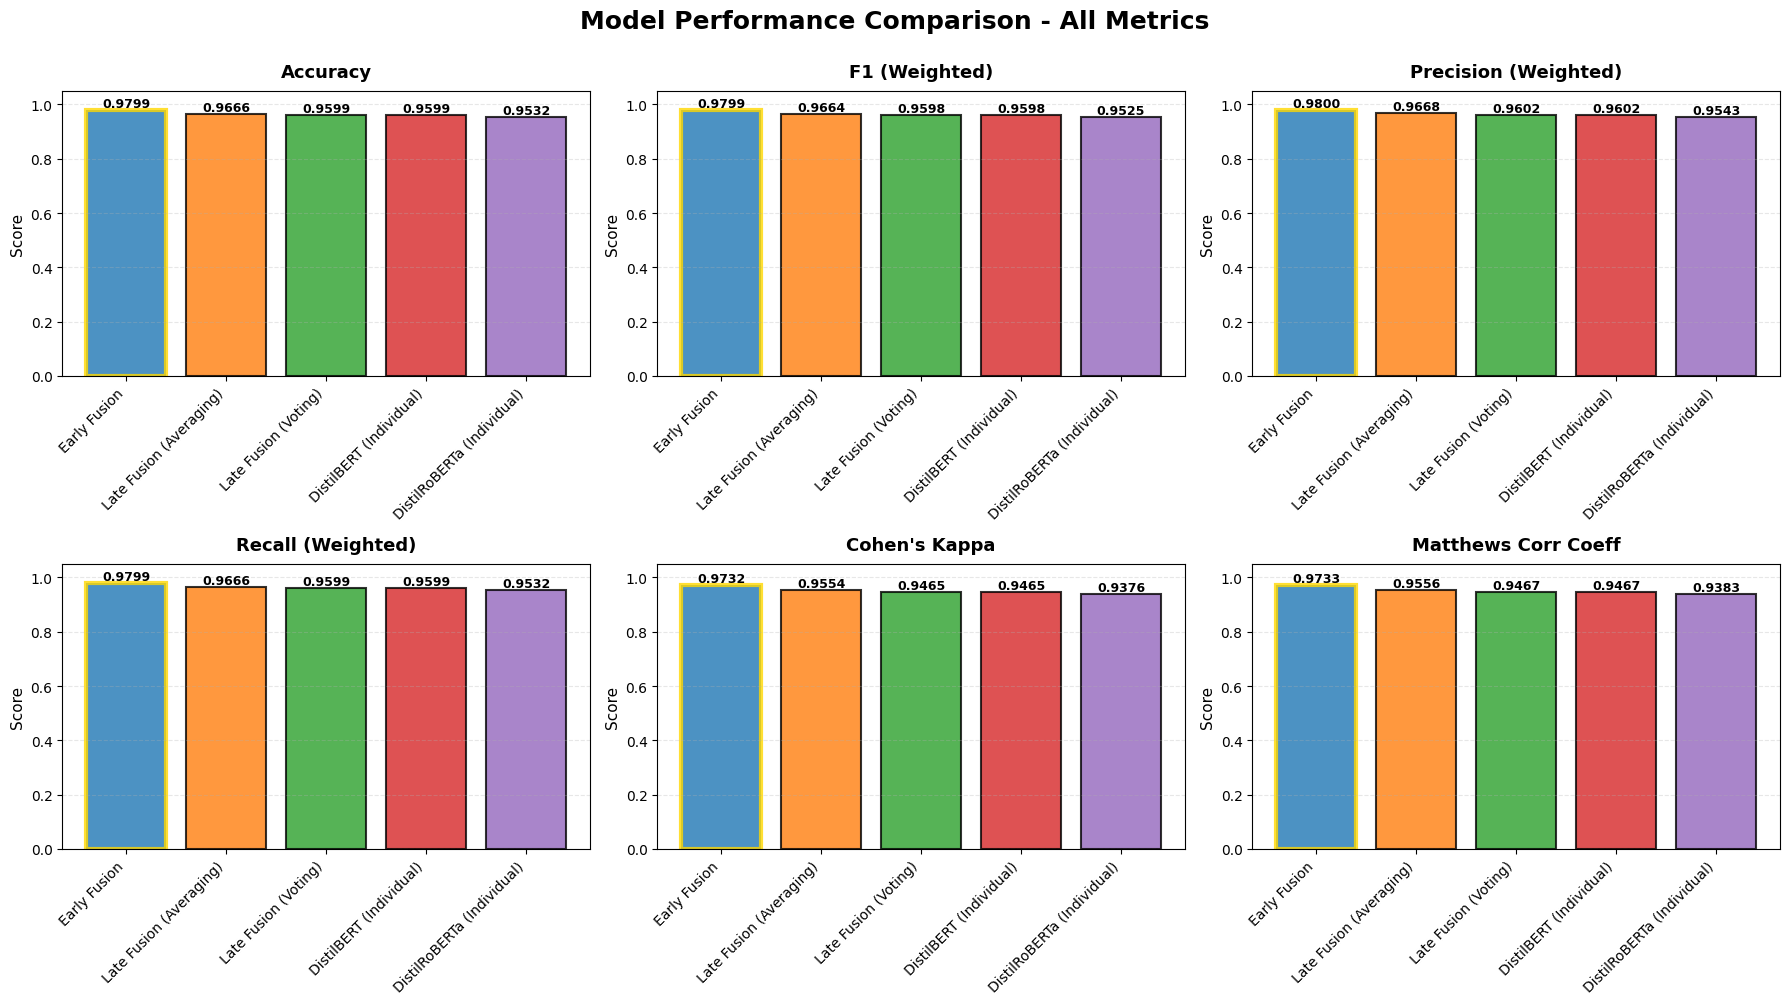


📊 Generating confusion matrices...


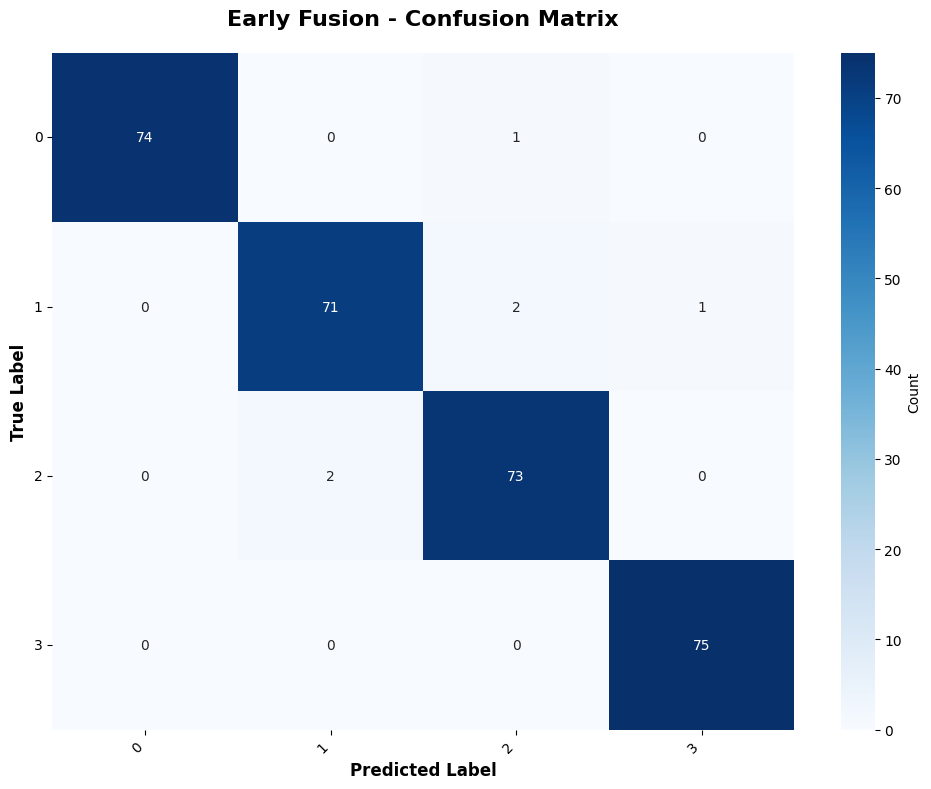

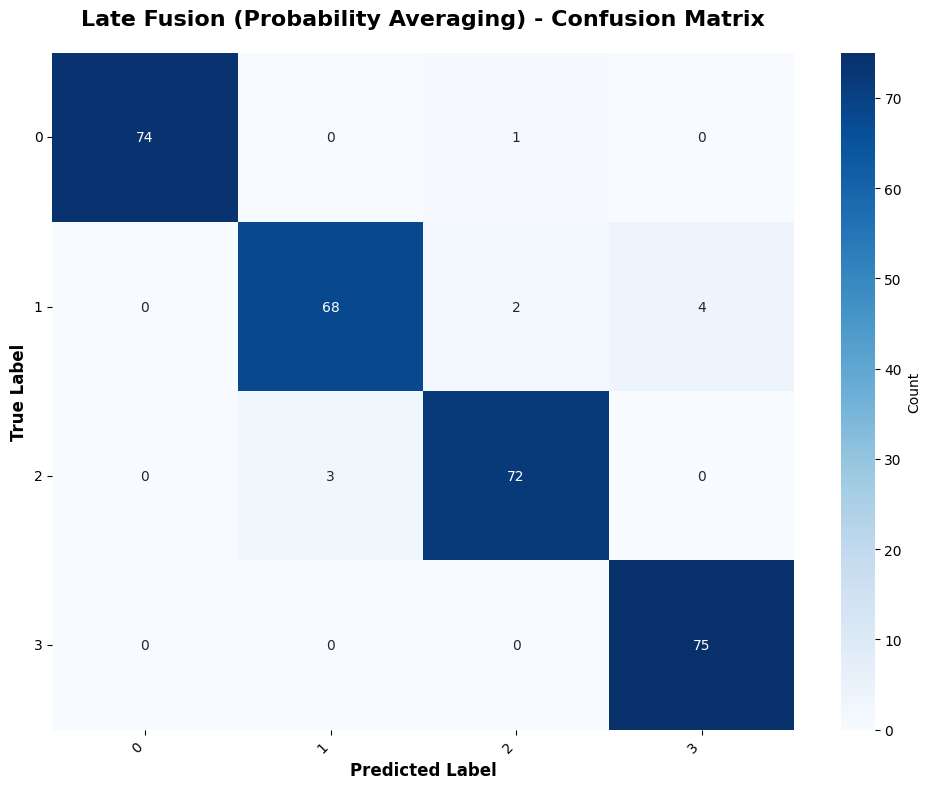

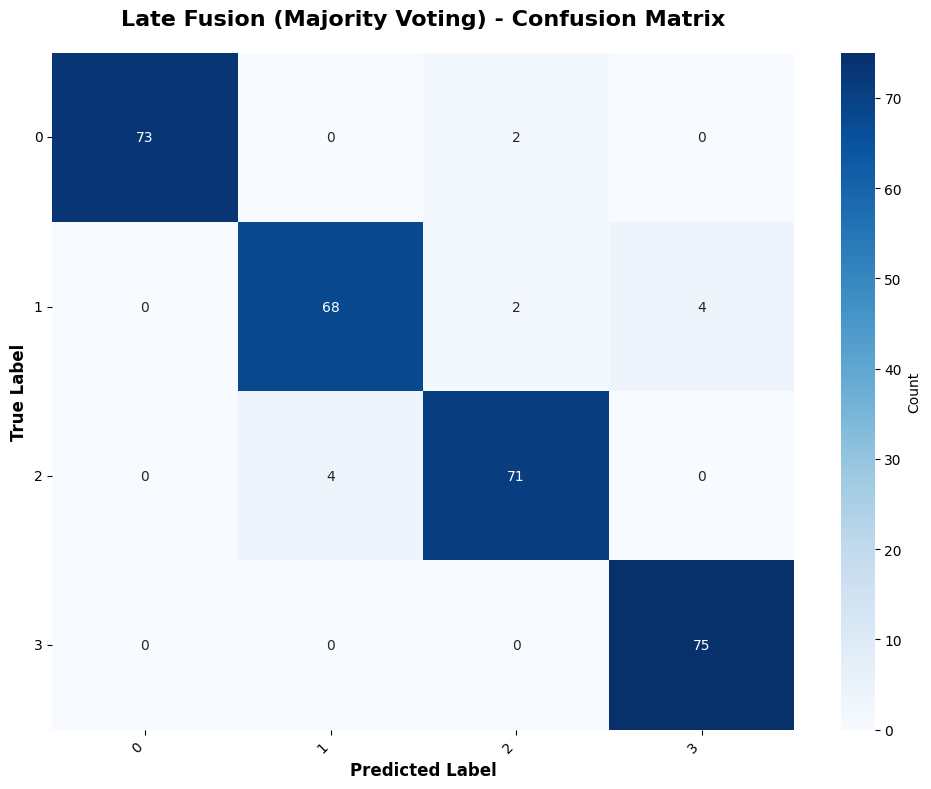


PERFORMANCE IMPROVEMENT ANALYSIS

📊 Late Fusion (Averaging) vs Individual Models:
   Average Individual F1: 0.9562
   Late Fusion (Avg) F1:  0.9664
   Improvement:           +0.0102 (+1.07%)वरुन)

📊 Late Fusion (Voting) vs Individual Models:
   Average Individual F1: 0.9562
   Late Fusion (Vote) F1: 0.9598
   Improvement:           +0.0036 (+0.38%)वरुन)

📊 Early Fusion vs Late Fusion (Best):
   Early Fusion F1:            0.9799
   Late Fusion (Averaging) F1: 0.9664
   Difference:                 -0.0135 (-1.38%)वरुन)

✅ COMPREHENSIVE EVALUATION COMPLETED SUCCESSFULLY!


In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# EVALUATION FUNCTIONS

def evaluate_early_fusion_model(model, dataset, device, batch_size=16):
    
    model.eval()

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=simple_collate_fn,
        num_workers=0
    )

    all_predictions = []
    all_probabilities = [] 
    all_labels = []

    print("Evaluating Early Fusion model...")
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            # Move batch to device
            bert_input_ids = batch['bert_input_ids'].to(device)
            bert_attention_mask = batch['bert_attention_mask'].to(device)
            roberta_input_ids = batch['roberta_input_ids'].to(device)
            roberta_attention_mask = batch['roberta_attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get model predictions
            outputs = model(
                bert_input_ids=bert_input_ids,
                bert_attention_mask=bert_attention_mask,
                roberta_input_ids=roberta_input_ids,
                roberta_attention_mask=roberta_attention_mask
            )

            # Get predicted class and probabilities
            predictions = torch.argmax(outputs.logits, dim=1)
            probabilities = torch.softmax(outputs.logits, dim=1) 

            # Store predictions and labels
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy()) 
            all_labels.extend(labels.cpu().numpy())

            if (batch_idx + 1) % 10 == 0:
                print(f"  Processed {batch_idx + 1}/{len(dataloader)} batches")

    return np.array(all_predictions), np.array(all_probabilities), np.array(all_labels)


def get_model_predictions(model, dataloader, device):
    
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # Move inputs to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get model outputs
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # Get probabilities
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(logits, dim=1)

            # Store results
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        np.array(all_predictions),
        np.array(all_probabilities),
        np.array(all_labels)
    )


def evaluate_late_fusion_model(
    distilbert_model,
    distilroberta_model,
    bert_dataset,
    roberta_dataset,
    device,
    batch_size=16,
    fusion_method='average'
):
    
    print(f"Evaluating Late Fusion model ({fusion_method})...")

    # Create dataloaders
    bert_dataloader = DataLoader(
        bert_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    roberta_dataloader = DataLoader(
        roberta_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Get predictions from DistilBERT
    print("  Getting DistilBERT predictions...")
    bert_preds, bert_probs, true_labels = get_model_predictions(
        distilbert_model,
        bert_dataloader,
        device
    )

    # Get predictions from DistilRoBERTa
    print("  Getting DistilRoBERTa predictions...")
    roberta_preds, roberta_probs, _ = get_model_predictions(
        distilroberta_model,
        roberta_dataloader,
        device
    )

    
    combined_probs = (bert_probs + roberta_probs) / 2 

    
    if fusion_method == 'average':
        final_predictions = np.argmax(combined_probs, axis=1) 
    elif fusion_method == 'voting':
        final_predictions = []
        for bert_pred, roberta_pred in zip(bert_preds, roberta_preds):
            if bert_pred == roberta_pred:
                final_predictions.append(bert_pred)
            else:
                final_predictions.append(bert_pred) 
        final_predictions = np.array(final_predictions)

    return final_predictions, combined_probs, true_labels 


def calculate_all_metrics(y_true, y_pred, model_name):
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 (Weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Precision (Weighted)': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall (Weighted)': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
        'Matthews Corr Coeff': matthews_corrcoef(y_true, y_pred)
    }

    return metrics


def plot_metrics_comparison(results_df, title='Model Performance Comparison'):
   
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title, fontsize=18, fontweight='bold', y=1.00)

    metrics = ['Accuracy', 'F1 (Weighted)', 'Precision (Weighted)',
               'Recall (Weighted)', "Cohen's Kappa", 'Matthews Corr Coeff']

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for idx, (ax, metric) in enumerate(zip(axes.flatten(), metrics)):
        # Create bar plot
        bars = ax.bar(
            range(len(results_df)),
            results_df[metric],
            color=colors[:len(results_df)],
            alpha=0.8,
            edgecolor='black',
            linewidth=1.5
        )

        # Customize plot
        ax.set_title(metric, fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_xticks(range(len(results_df)))
        ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'{height:.4f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

        # Highlight best performance
        best_idx = results_df[metric].idxmax()
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, title='Confusion Matrix', figsize=(10, 8)):
    
    plt.figure(figsize=figsize)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count'}
    )

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


#MAIN EVALUATION SCRIPT 
print("="*100)
print("COMPREHENSIVE MODEL EVALUATION - EARLY FUSION vs LATE FUSION")
print("="*100)

# Get class names
class_names = label_encoder.classes_
num_labels = len(class_names)

print(f"\n📋 Dataset Info:")
print(f"   Number of classes: {num_labels}")
print(f"   Classes: {', '.join(map(str, class_names))}")
print(f"   Validation samples: {len(val_dataset)}")

# Store all results
all_results = []

# EVALUATE EARLY FUSION MODEL 
print("\n" + "="*100)
print("1. EVALUATING EARLY FUSION MODEL")
print("="*100)

y_pred_early, probs_early, y_true_early = evaluate_early_fusion_model( # Capture probabilities
    early_fusion_model,
    val_dataset,
    device,
    batch_size=16
)

print(f"✅ Early Fusion evaluation complete!")

# Calculate metrics for Early Fusion
early_fusion_metrics = calculate_all_metrics(
    y_true_early,
    y_pred_early,
    'Early Fusion'
)
all_results.append(early_fusion_metrics)

# Confusion matrix for Early Fusion
cm_early = confusion_matrix(y_true_early, y_pred_early)

#LOAD LATE FUSION MODELS
print("\n" + "="*100)
print("2. LOADING LATE FUSION MODELS")
print("="*100)

print("📥 Loading trained individual models...")
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "./distilbert_individual"
).to(device)
distilroberta_model = AutoModelForSequenceClassification.from_pretrained(
    "./distilroberta_individual"
).to(device)
print("✅ Models loaded successfully!")

#EVALUATE LATE FUSION (PROBABILITY AVERAGING)
print("\n" + "="*100)
print("3. EVALUATING LATE FUSION - PROBABILITY AVERAGING")
print("="*100)

y_pred_late_avg, probs_late_avg, y_true_late = evaluate_late_fusion_model( 
    distilbert_model,
    distilroberta_model,
    val_dataset_bert,
    val_dataset_roberta,
    device,
    batch_size=16,
    fusion_method='average'
)

print(f"✅ Late Fusion (Averaging) evaluation complete!")

# Calculate metrics for Late Fusion (Averaging)
late_fusion_avg_metrics = calculate_all_metrics(
    y_true_late,
    y_pred_late_avg,
    'Late Fusion (Averaging)'
)
all_results.append(late_fusion_avg_metrics)

# Confusion matrix for Late Fusion (Averaging)
cm_late_avg = confusion_matrix(y_true_late, y_pred_late_avg)

#EVALUATE LATE FUSION (MAJORITY VOTING) 
print("\n" + "="*100)
print("4. EVALUATING LATE FUSION - MAJORITY VOTING")
print("="*100)


y_pred_late_vote, probs_late_vote, y_true_late_vote = evaluate_late_fusion_model( 
    distilbert_model,
    distilroberta_model,
    val_dataset_bert,
    val_dataset_roberta,
    device,
    batch_size=16,
    fusion_method='voting'
)

print(f"✅ Late Fusion (Voting) evaluation complete!")

# Calculate metrics for Late Fusion (Voting)
late_fusion_vote_metrics = calculate_all_metrics(
    y_true_late_vote,
    y_pred_late_vote,
    'Late Fusion (Voting)'
)
all_results.append(late_fusion_vote_metrics)

# Confusion matrix for Late Fusion (Voting)
cm_late_vote = confusion_matrix(y_true_late_vote, y_pred_late_vote)

#EVALUATE INDIVIDUAL MODELS
print("\n" + "="*100)
print("5. EVALUATING INDIVIDUAL MODELS (FOR REFERENCE)")
print("="*100)

# DistilBERT individual
print("  Evaluating DistilBERT...")
bert_dataloader = DataLoader(val_dataset_bert, batch_size=16, shuffle=False)
y_pred_bert, probs_distilbert, y_true_bert = get_model_predictions(distilbert_model, bert_dataloader, device) # Capture probabilities
bert_metrics = calculate_all_metrics(y_true_bert, y_pred_bert, 'DistilBERT (Individual)')
all_results.append(bert_metrics)

# DistilRoBERTa individual
print("  Evaluating DistilRoBERTa...")
roberta_dataloader = DataLoader(val_dataset_roberta, batch_size=16, shuffle=False)
y_pred_roberta, probs_distilroberta, y_true_roberta = get_model_predictions(distilroberta_model, roberta_dataloader, device) # Capture probabilities
roberta_metrics = calculate_all_metrics(y_true_roberta, y_pred_roberta, 'DistilRoBERTa (Individual)')
all_results.append(roberta_metrics)

print(f"✅ Individual models evaluation complete!")


y_test = y_true_early 

#CREATE RESULTS DATAFRAME
results_df = pd.DataFrame(all_results)

# Round all numeric columns to 4 decimal places
numeric_cols = ['Accuracy', 'F1 (Weighted)', 'Precision (Weighted)',
                'Recall (Weighted)', "Cohen's Kappa", 'Matthews Corr Coeff']
results_df[numeric_cols] = results_df[numeric_cols].round(4)

#DISPLAY RESULTS
print("\n" + "="*100)
print("COMPREHENSIVE METRICS COMPARISON")
print("="*100)
print("\n")
print(results_df.to_string(index=False))
print("\n" + "="*100)

#IDENTIFY BEST MODEL 
print("\n" + "="*100)
print("BEST MODEL PER METRIC")
print("="*100)

for metric in numeric_cols:
    best_idx = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'Model']
    best_score = results_df.loc[best_idx, metric]
    print(f"🏆 {metric:25s}: {best_model:30s} ({best_score:.4f})")

# Overall best model (based on F1 score)
best_overall_idx = results_df['F1 (Weighted)'].idxmax()
best_overall_model = results_df.loc[best_overall_idx, 'Model']
best_overall_f1 = results_df.loc[best_overall_idx, 'F1 (Weighted)']

print("\n" + "="*100)
print(f"🏆 OVERALL BEST MODEL (Based on F1 Score): {best_overall_model} (F1: {best_overall_f1:.4f})")
print("="*100)

# SAVE RESULTS TO CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print("\n💾 Results saved to 'model_comparison_results.csv'")

# DETAILED CLASSIFICATION REPORTS 
print("\n" + "="*100)
print("DETAILED CLASSIFICATION REPORTS")
print("="*100)

print("\n" + "-"*100)
print("EARLY FUSION MODEL")
print("-"*100)
print(classification_report(y_true_early, y_pred_early, target_names=[str(c) for c in class_names], digits=4))

print("\n" + "-"*100)
print("LATE FUSION (PROBABILITY AVERAGING)")
print("-"*100)
print(classification_report(y_true_late, y_pred_late_avg, target_names=[str(c) for c in class_names], digits=4))

print("\n" + "-"*100)
print("LATE FUSION (MAJORITY VOTING)")
print("-"*100)
print(classification_report(y_true_late_vote, y_pred_late_vote, target_names=[str(c) for c in class_names], digits=4))

#  VISUALIZATIONS 
print("\n Generating visualization plots...")

# Plot metrics comparison
plot_metrics_comparison(results_df, title='Model Performance Comparison - All Metrics')

# Plot confusion matrices for main models
print("\n Generating confusion matrices...")

plot_confusion_matrix(
    cm_early,
    [str(c) for c in class_names],
    title='Early Fusion - Confusion Matrix'
)

plot_confusion_matrix(
    cm_late_avg,
    [str(c) for c in class_names],
    title='Late Fusion (Probability Averaging) - Confusion Matrix'
)

plot_confusion_matrix(
    cm_late_vote,
    [str(c) for c in class_names],
    title='Late Fusion (Majority Voting) - Confusion Matrix'
)

# PERFORMANCE IMPROVEMENT ANALYSIS 
print("\n" + "="*100)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*100)

# Compare Late Fusion vs Individual models
bert_f1 = results_df[results_df['Model'] == 'DistilBERT (Individual)']['F1 (Weighted)'].values[0]
roberta_f1 = results_df[results_df['Model'] == 'DistilRoBERTa (Individual)']['F1 (Weighted)'].values[0]
late_avg_f1 = results_df[results_df['Model'] == 'Late Fusion (Averaging)']['F1 (Weighted)'].values[0]
late_vote_f1 = results_df[results_df['Model'] == 'Late Fusion (Voting)']['F1 (Weighted)'].values[0]
early_f1 = results_df[results_df['Model'] == 'Early Fusion']['F1 (Weighted)'].values[0]

avg_individual_f1 = (bert_f1 + roberta_f1) / 2

print(f"\n Late Fusion (Averaging) vs Individual Models:")
print(f"   Average Individual F1: {avg_individual_f1:.4f}")
print(f"   Late Fusion (Avg) F1:  {late_avg_f1:.4f}")
print(f"   Improvement:           {late_avg_f1 - avg_individual_f1:+.4f} ({((late_avg_f1 - avg_individual_f1) / avg_individual_f1 * 100):+.2f}%)वरुन)")

print(f"\n Late Fusion (Voting) vs Individual Models:")
print(f"   Average Individual F1: {avg_individual_f1:.4f}")
print(f"   Late Fusion (Vote) F1: {late_vote_f1:.4f}")
print(f"   Improvement:           {late_vote_f1 - avg_individual_f1:+.4f} ({((late_vote_f1 - avg_individual_f1) / avg_individual_f1 * 100):+.2f}%)वरुन)")

print(f"\n Early Fusion vs Late Fusion (Best):")
best_late_f1 = max(late_avg_f1, late_vote_f1)
best_late_method = "Averaging" if late_avg_f1 > late_vote_f1 else "Voting"
print(f"   Early Fusion F1:            {early_f1:.4f}")
print(f"   Late Fusion ({best_late_method}) F1: {best_late_f1:.4f}")
print(f"   Difference:                 {best_late_f1 - early_f1:+.4f} ({((best_late_f1 - early_f1) / early_f1 * 100):+.2f}%)वरुन)")

print("\n" + "="*100)
print(" COMPREHENSIVE EVALUATION COMPLETED SUCCESSFULLY!")
print("="*100)

new

In [ ]:
# Calibration metrics: ECE and Brier score 

import numpy as np
from sklearn.metrics import brier_score_loss



num_classes = probs_early.shape[1]

def compute_ece(probs, labels, n_bins=10):
    """
    Expected Calibration Error (ECE) using equal-width bins.

    probs:  (N, C) predicted probabilities
    labels: (N,)   true integer labels in [0, C-1]
    """
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)

    ece = 0.0
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for i in range(n_bins):
        bin_lower, bin_upper = bin_edges[i], bin_edges[i + 1]
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            acc_in_bin = (predictions[in_bin] == labels[in_bin]).mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += np.abs(acc_in_bin - conf_in_bin) * prop_in_bin

    return ece

def compute_multiclass_brier(probs, labels, num_classes):
    """
    Macro-style multiclass Brier score (mean per-sample squared error
    between predicted probability vector and one-hot label).
    """
    one_hot = np.eye(num_classes)[labels]           
    return np.mean(np.sum((probs - one_hot) ** 2, axis=1))

calibration_results = {}
for name, probs in {
    "Early Fusion": probs_early,
    "Late Fusion (Averaging)": probs_late_avg,
    "Late Fusion (Voting)": probs_late_vote, 
    "DistilBERT (Individual)": probs_distilbert,
    "DistilRoBERTa (Individual)": probs_distilroberta,
}.items():
    ece = compute_ece(probs, y_test, n_bins=10)
    brier = compute_multiclass_brier(probs, y_test, num_classes)
    calibration_results[name] = {"ECE": ece, "Brier": brier}

print("Calibration results (ECE, Brier) on test set:")
for name, vals in calibration_results.items():
    print(f"{name:28s}  ECE = {vals['ECE']:.4f},  Brier = {vals['Brier']:.4f}")

Calibration results (ECE, Brier) on test set:
Early Fusion                  ECE = 0.0200,  Brier = 0.0401
Late Fusion (Averaging)       ECE = 0.0306,  Brier = 0.0651
Late Fusion (Voting)          ECE = 0.0306,  Brier = 0.0651
DistilBERT (Individual)       ECE = 0.0372,  Brier = 0.0743
DistilRoBERTa (Individual)    ECE = 0.0436,  Brier = 0.0912


In [ ]:
# Statistical analysis: bootstrap CIs and McNemar tests

from sklearn.metrics import f1_score
from statsmodels.stats.contingency_tables import mcnemar

rng = np.random.default_rng(42)

def bootstrap_ci_macro_f1(y_true, probs, n_boot=10000, alpha=0.05):
    """
    Bootstrap 95% CI for macro-averaged F1.
    """
    preds = probs.argmax(axis=1)
    N = len(y_true)
    scores = []

    for _ in range(n_boot):
        idx = rng.integers(0, N, size=N)
        scores.append(f1_score(y_true[idx], preds[idx], average="macro"))

    scores = np.array(scores)
    mean_f1 = scores.mean()
    lower = np.percentile(scores, 100 * (alpha / 2))
    upper = np.percentile(scores, 100 * (1 - alpha / 2))
    return mean_f1, lower, upper

def mcnemar_test(y_true, probs_a, probs_b):
    """
    McNemar's test on per-sample correctness of two models.
    Returns (chi2_stat, p_value).
    """
    pred_a = probs_a.argmax(axis=1)
    pred_b = probs_b.argmax(axis=1)

    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    # Contingency table: 
    n_a_corr_b_corr = np.sum(correct_a & correct_b)
    n_a_corr_b_incorr = np.sum(correct_a & ~correct_b)
    n_a_incorr_b_corr = np.sum(~correct_a & correct_b)
    n_a_incorr_b_incorr = np.sum(~correct_a & ~correct_b)

    table = [[n_a_corr_b_corr, n_a_corr_b_incorr],
             [n_a_incorr_b_corr, n_a_incorr_b_incorr]]

  
    if n_a_corr_b_incorr == 0 and n_a_incorr_b_corr == 0:
        
        return 0.0, 1.0  

    result = mcnemar(table, exact=False, correction=True)
    return result.statistic, result.pvalue

# Bootstrap CIs for key models 

ci_results = {}
for name, probs in {
    "Early Fusion": probs_early,
    "Late Fusion (Averaging)": probs_late_avg,
    "DistilRoBERTa (Individual)": probs_distilroberta,
}.items():
    mean_f1, lo, hi = bootstrap_ci_macro_f1(y_test, probs, n_boot=10000)
    ci_results[name] = {"mean_macro_f1": mean_f1, "ci_lower": lo, "ci_upper": hi}

print("Bootstrap macro F1 (mean and 95% CI):")
for name, vals in ci_results.items():
    print(f"{name:28s}  F1 = {vals['mean_macro_f1']:.4f} "
          f"[{vals['ci_lower']:.4f}, {vals['ci_upper']:.4f}]")

# McNemar tests: Early Fusion vs baselines 

for comp_name, probs_other in {
    "DistilRoBERTa (Individual)": probs_distilroberta,
    "Late Fusion (Averaging)": probs_late_avg,
}.items():
    chi2_stat, p_val = mcnemar_test(y_test, probs_early, probs_other)
    print(f"\nMcNemar test: Early Fusion vs {comp_name}")
    print(f"Chi-square = {chi2_stat:.4f}, p-value = {p_val:.4e}")

Bootstrap macro F1 (mean and 95% CI):
Early Fusion                  F1 = 0.9798 [0.9620, 0.9935]
Late Fusion (Averaging)       F1 = 0.9662 [0.9444, 0.9856]
DistilRoBERTa (Individual)    F1 = 0.9520 [0.9264, 0.9754]

McNemar test: Early Fusion vs DistilRoBERTa (Individual)
Chi-square = 3.5000, p-value = 6.1369e-02

McNemar test: Early Fusion vs Late Fusion (Averaging)
Chi-square = 2.2500, p-value = 1.3361e-01
